<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/ClassificationForTitanicDatasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
!pip install pyspark

In [45]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Titanic Survival Prediction") \
    .getOrCreate()

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the Titanic Dataset

In [47]:
import pandas as pd

# Read CSV with pandas
titanic_pd = pd.read_csv('/content/drive/MyDrive/UEL/titanic_synthetic_data.csv')

# Convert to Spark DataFrame
titanic_df = spark.createDataFrame(titanic_pd)
titanic_df.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7| 397.0017836778202|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows



In [48]:
# Check for missing values
from pyspark.sql.functions import col, isnan, when, count
titanic_df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in titanic_df.columns]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



## Handle Missing Values

In [49]:
from pyspark.ml.feature import Imputer

# Identify numerical columns with null values
numerical_cols = ['Age', 'Fare']
imputer = Imputer(inputCols=numerical_cols,
                 outputCols=numerical_cols,
                 strategy="median")
titanic_df = imputer.fit(titanic_df).transform(titanic_df)

## Feature Engineering

In [50]:
from pyspark.ml.feature import Imputer, VectorAssembler, StandardScaler
from pyspark.sql.functions import col, when, log
# Define feature columns (excluding target and any non-feature columns)
feature_cols = [c for c in titanic_df.columns if c not in ['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin']]

# Assemble features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
titanic_df = assembler.transform(titanic_df)

# Standardize features
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
titanic_df = scaler.fit(titanic_df).transform(titanic_df)

## Handle Class Imbalance

In [51]:
# Calculate class weights
total_count = titanic_df.count()
num_survived = titanic_df.filter(col("Survived") == 1).count()
survived_ratio = num_survived / total_count
not_survived_ratio = 1 - survived_ratio

# Add class weights
titanic_df = titanic_df.withColumn(
    "class_weight",
    when(col("Survived") == 1, not_survived_ratio).otherwise(survived_ratio)
)

print(f"Survived ratio: {survived_ratio:.4f}")
print(f"Not survived ratio: {not_survived_ratio:.4f}")

Survived ratio: 0.4999
Not survived ratio: 0.5001


## Feature Selection (UnivariateFeatureSelector)

In [52]:
from pyspark.ml.feature import UnivariateFeatureSelector
from pyspark.sql.functions import size

# Initialize selector
selector = UnivariateFeatureSelector(
    featuresCol="features",
    outputCol="selected_features",
    labelCol="Survived",
    selectionMode="fpr"
)

# Set parameters
selector.setFeatureType("continuous")
selector.setLabelType("categorical")
selector.setSelectionThreshold(0.05)

# Apply feature selection
# Drop the output column if it already exists
if "selected_features" in titanic_df.columns:
    titanic_df = titanic_df.drop("selected_features")

model = selector.fit(titanic_df)
titanic_df = model.transform(titanic_df)

# Check the size of the selected features vector
selected_features_size = titanic_df.select("selected_features").first()[0].size

if selected_features_size == 0:
    print("UnivariateFeatureSelector selected 0 features. Consider adjusting the selection threshold.")
else:
    print(f"UnivariateFeatureSelector selected {selected_features_size} features.")

UnivariateFeatureSelector selected 0 features. Consider adjusting the selection threshold.


## Train-Test Split

In [53]:
train_df, test_df = titanic_df.randomSplit([0.7, 0.3], seed=42)

## Train Logistic Regression Model

In [54]:
import pyspark.ml.classification
from pyspark.ml.classification import LogisticRegression
# Initialize logistic regression
lr = LogisticRegression(
    featuresCol="features",  # Make sure this matches your feature column name
    labelCol="Survived",
    weightCol="class_weight",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.8,
    family="binomial"  # Explicitly set for binary classification
)

# Train model
try:
    model = lr.fit(train_df)
except Exception as e:
    print(f"Error during model training: {e}")
    raise

## Evaluate Model

In [55]:
import pyspark.ml.evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
# Make predictions
predictions = model.transform(test_df)

# Calculate evaluation metrics
evaluator = BinaryClassificationEvaluator(labelCol="Survived", rawPredictionCol="rawPrediction")
auc = evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})

multi_evaluator = MulticlassClassificationEvaluator(labelCol="Survived", predictionCol="prediction")
accuracy = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "accuracy"})
precision = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "weightedPrecision"})
recall = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "weightedRecall"})
f1 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "f1"})

print("\nModel Evaluation Metrics:")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
predictions.groupBy("Survived", "prediction").count().show()

# Show sample predictions
print("\nSample Predictions:")
predictions.select("Survived", "prediction", "probability").show(10, truncate=False)


Model Evaluation Metrics:
AUC: 0.5000
Accuracy: 0.4994
Precision: 0.2494
Recall: 0.4994
F1 Score: 0.3326

Confusion Matrix:
+--------+----------+------+
|Survived|prediction| count|
+--------+----------+------+
|       0|       1.0|150208|
|       1|       1.0|149823|
+--------+----------+------+


Sample Predictions:
+--------+----------+---------------------------------------+
|Survived|prediction|probability                            |
+--------+----------+---------------------------------------+
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|1       |1.0       |[0.4997807103413054,0.5002192896586946]|
|0       |1.0       |[0.4997807103413054,0.5002192896586946]|
|0       |1.0       |[0.4997807103413054,0.5002192896586946

## Feature Importance Analysis

In [56]:
# Get coefficients and feature names
coefficients = model.coefficients.toArray()
feature_names = feature_cols  # Use original feature names

# Map coefficients to feature names (since we did feature selection, we need to check which were kept)
# This requires examining the selector model to see which features were selected
try:
    selected_indices = model.selectedFeatures
    selected_feature_names = [feature_names[i] for i in selected_indices]

    # Create list of (feature_name, coefficient) pairs
    feature_importance = list(zip(selected_feature_names, coefficients))

    # Sort by absolute value of coefficients
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

    print("\nTop Important Features:")
    for name, importance in feature_importance:
        print(f"{name}: {importance:.4f}")
except AttributeError:
    print("Could not extract feature importance - using all features")
    feature_importance = list(zip(feature_names, coefficients))
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    print("\nTop Important Features:")
    for name, importance in feature_importance[:5]:  # Show top 5
        print(f"{name}: {importance:.4f}")

Could not extract feature importance - using all features

Top Important Features:
Pclass: 0.0000
Age: 0.0000
SibSp: 0.0000
Parch: 0.0000
Fare: 0.0000


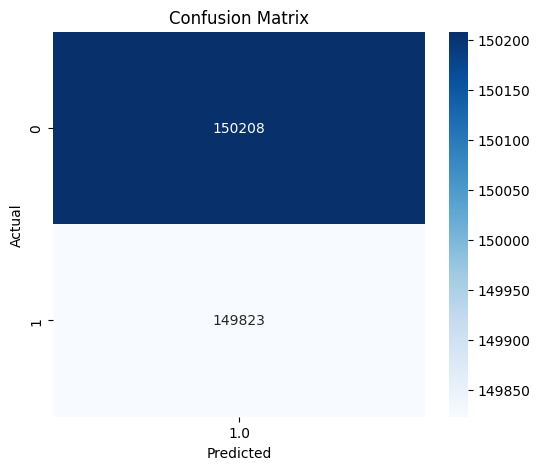

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert Spark DataFrame to Pandas for visualization
pd_predictions = predictions.select("Survived", "prediction").toPandas()

# Confusion matrix heatmap
conf_matrix = pd.crosstab(pd_predictions['Survived'], pd_predictions['prediction'],
                         rownames=['Actual'], colnames=['Predicted'])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()